Using device: cuda
GPU: Tesla T4


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Train path: /kaggle/input/datasets/abidarahman1997/dataset1/Dataset1/train/images
Test path: /kaggle/input/datasets/abidarahman1997/dataset1/Dataset1/test/images
Train images: 2533
Test images: 318


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsam

Model: DETR ResNet-50
Parameters: 41502923
Epoch 1/30 completed | Average loss: 1.5059 | Time: 463.90 sec
Epoch 2/30 completed | Average loss: 1.1323 | Time: 438.67 sec
Epoch 3/30 completed | Average loss: 0.9589 | Time: 437.99 sec
Epoch 4/30 completed | Average loss: 1.2523 | Time: 437.93 sec
Epoch 5/30 completed | Average loss: 0.8606 | Time: 438.22 sec
Epoch 6/30 completed | Average loss: 0.7871 | Time: 438.06 sec
Epoch 7/30 completed | Average loss: 1.1170 | Time: 437.40 sec
Epoch 8/30 completed | Average loss: 1.0302 | Time: 444.16 sec
Epoch 9/30 completed | Average loss: 0.8217 | Time: 438.00 sec
Epoch 10/30 completed | Average loss: 0.8477 | Time: 437.98 sec
Epoch 11/30 completed | Average loss: 0.7705 | Time: 438.08 sec
Epoch 12/30 completed | Average loss: 0.9969 | Time: 438.43 sec
Epoch 13/30 completed | Average loss: 0.8692 | Time: 438.21 sec
Epoch 14/30 completed | Average loss: 1.2495 | Time: 438.15 sec
Epoch 15/30 completed | Average loss: 0.8028 | Time: 438.44 sec
Epoch 

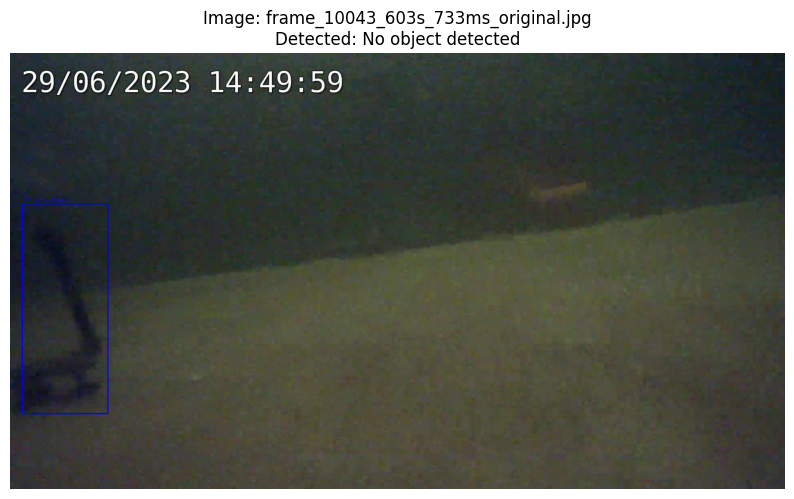

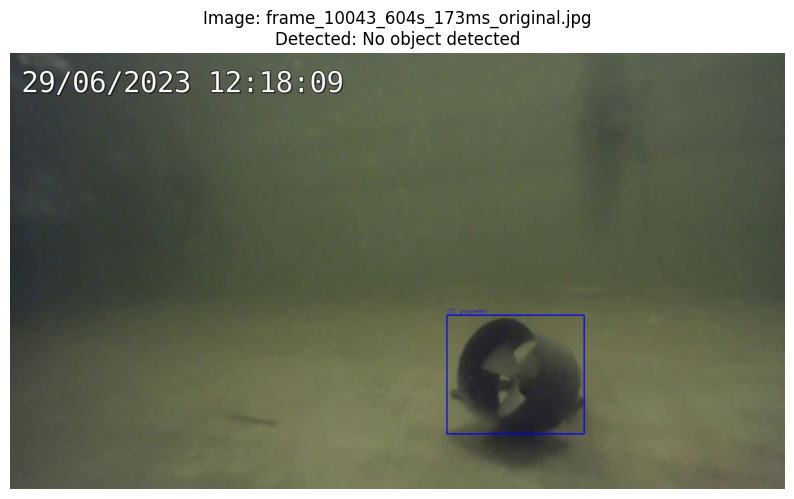

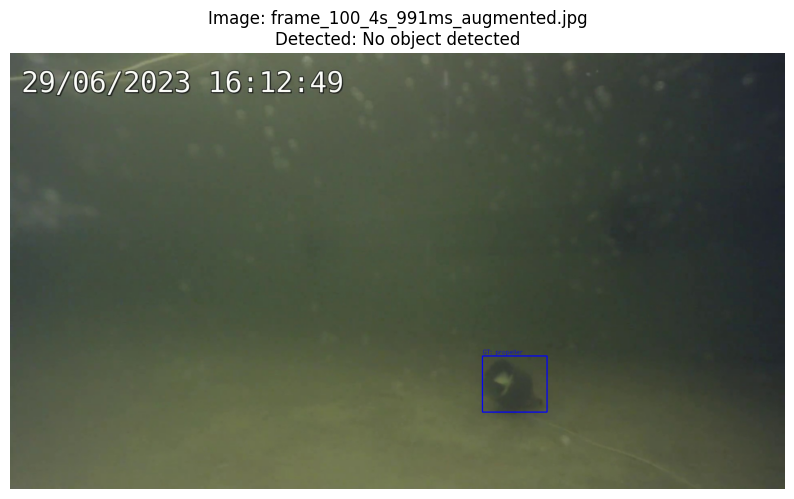

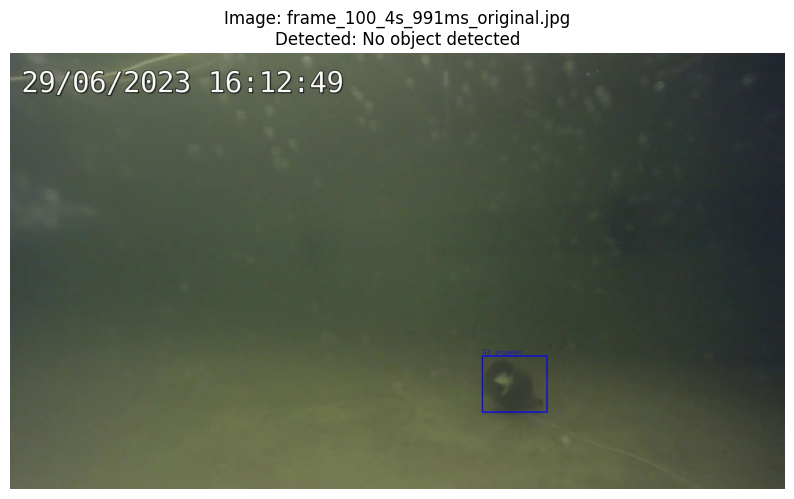

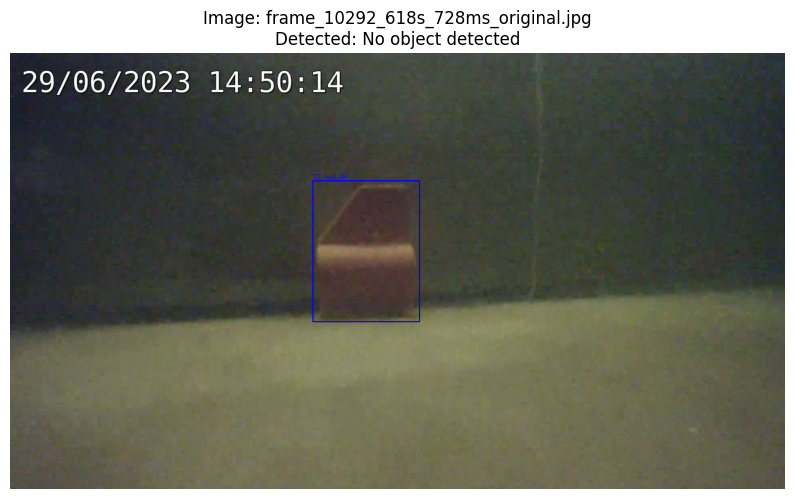


Final summary:
{
  "model": "DETR ResNet-50",
  "parameters": 41502923,
  "training_time_seconds": 13175.057315587997,
  "avg_inference_time_seconds": 0.12337562123184684,
  "total_test_inference_time_seconds": 19.616723775863647,
  "fps": 16.210657989244165,
  "map50_percent": 45.199623107910156,
  "map50_95_percent": 31.375131607055664,
  "precision_percent": 64.52830188679245,
  "recall_percent": 39.310344827586206,
  "detection_accuracy_percent": 64.52830188679245,
  "batch_size_train": 2,
  "batch_size_test": 2,
  "num_epochs": 30,
  "confidence_threshold": 0.5
}


In [1]:
!pip install -q transformers torchmetrics opencv-python pillow matplotlib

import os, cv2, glob, json, time, random, gc, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import DetrImageProcessor, DetrForObjectDetection

warnings.filterwarnings("ignore")

# =========================
# Speed settings
# =========================
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if torch.cuda.is_available():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# Paths
# =========================
DATASET_PATH = "/kaggle/input/datasets/abidarahman1997/dataset1/Dataset1"

TRAIN_IMG = f"{DATASET_PATH}/train/images"
TRAIN_LBL = f"{DATASET_PATH}/train/labels"

TEST_IMG = f"{DATASET_PATH}/test/images"
TEST_LBL = f"{DATASET_PATH}/test/labels"

RESULTS_DIR = "/kaggle/working/detr_resnet50_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# =========================
# Config
# =========================
CLASSES = ["propeller", "pipe_type2", "red_fin", "net", "qr_codes", "pipe"]

NUM_CLASSES = len(CLASSES)

CONF_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
VIS_SAMPLES = 5

BATCH_SIZE_TRAIN = 2
BATCH_SIZE_TEST = 2

NUM_EPOCHS = 30
NUM_WORKERS = 2

# For quick test, use:
# NUM_EPOCHS = 1

# =========================
# Helper functions
# =========================
def list_images(folder):
    return sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.jpeg")) +
        glob.glob(os.path.join(folder, "*.png"))
    )

def read_yolo_labels_xywh(txt_file, W, H):
    """
    Returns boxes in COCO absolute xywh format:
    [x_min, y_min, width, height]
    Labels are 0-based for DETR.
    """
    boxes, labels = [], []

    if not os.path.exists(txt_file):
        return boxes, labels

    with open(txt_file, "r") as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            c, x, y, w, h = parts
            c = int(float(c))
            x, y, w, h = map(float, [x, y, w, h])

            x_min = (x - w / 2) * W
            y_min = (y - h / 2) * H
            box_w = w * W
            box_h = h * H

            x_min = max(0, min(x_min, W - 1))
            y_min = max(0, min(y_min, H - 1))
            box_w = max(1, min(box_w, W - x_min))
            box_h = max(1, min(box_h, H - y_min))

            if box_w <= 1 or box_h <= 1:
                continue

            boxes.append([x_min, y_min, box_w, box_h])
            labels.append(c)

    return boxes, labels

def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def iou_xyxy(a, b):
    xA = max(a[0], b[0])
    yA = max(a[1], b[1])
    xB = min(a[2], b[2])
    yB = min(a[3], b[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    areaA = max(0, a[2] - a[0]) * max(0, a[3] - a[1])
    areaB = max(0, b[2] - b[0]) * max(0, b[3] - b[1])

    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0

# =========================
# Dataset
# =========================
class YOLOToDETRDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images = list_images(images_dir)
        self.labels_dir = labels_dir

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]

        image = Image.open(img_path).convert("RGB")
        W, H = image.size

        label_path = os.path.join(
            self.labels_dir,
            os.path.splitext(os.path.basename(img_path))[0] + ".txt"
        )

        boxes_xywh, labels = read_yolo_labels_xywh(label_path, W, H)

        annotations = []

        for box, label in zip(boxes_xywh, labels):
            x, y, w, h = box

            annotations.append({
                "bbox": [float(x), float(y), float(w), float(h)],
                "category_id": int(label),
                "area": float(w * h),
                "iscrowd": 0
            })

        target = {
            "image_id": idx,
            "annotations": annotations
        }

        return image, target

# =========================
# Processor
# =========================
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

def collate_fn(batch):
    images = [item[0] for item in batch]
    annotations = [item[1] for item in batch]

    encoding = processor(
        images=images,
        annotations=annotations,
        return_tensors="pt"
    )

    pixel_values = encoding["pixel_values"]
    pixel_mask = encoding["pixel_mask"]
    labels = encoding["labels"]

    return pixel_values, pixel_mask, labels, images, annotations

# =========================
# DataLoaders
# =========================
train_dataset = YOLOToDETRDataset(TRAIN_IMG, TRAIN_LBL)
test_dataset = YOLOToDETRDataset(TEST_IMG, TEST_LBL)

print("Train path:", TRAIN_IMG)
print("Test path:", TEST_IMG)
print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

if len(train_dataset) == 0:
    raise ValueError(f"No training images found in: {TRAIN_IMG}")

if len(test_dataset) == 0:
    raise ValueError(f"No test images found in: {TEST_IMG}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_TEST,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

# =========================
# Model
# =========================
MODEL_NAME = "DETR ResNet-50"

id2label = {i: name for i, name in enumerate(CLASSES)}
label2id = {name: i for i, name in enumerate(CLASSES)}

model = DetrForObjectDetection.from_pretrained(
    "facebook/detr-resnet-50",
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

model.to(DEVICE)

param_count = sum(p.numel() for p in model.parameters())

print("Model:", MODEL_NAME)
print("Parameters:", param_count)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-5,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

# =========================
# Training
# Prints only after every epoch
# =========================
train_start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    for pixel_values, pixel_mask, labels, _, _ in train_loader:
        pixel_values = pixel_values.to(DEVICE, non_blocking=True)
        pixel_mask = pixel_mask.to(DEVICE, non_blocking=True)

        labels = [
            {k: v.to(DEVICE, non_blocking=True) for k, v in t.items()}
            for t in labels
        ]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    epoch_time = time.time() - epoch_start
    avg_epoch_loss = epoch_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} completed | "
        f"Average loss: {avg_epoch_loss:.4f} | "
        f"Time: {epoch_time:.2f} sec"
    )

train_end = time.time()
training_seconds = train_end - train_start

print(f"\nTotal training time: {training_seconds:.2f} seconds")

# =========================
# Evaluation
# =========================
metric = MeanAveragePrecision(iou_type="bbox")
model.eval()

TP = 0
FP = 0
FN = 0
correct = 0
total_preds = 0
times = []

with torch.no_grad():
    for pixel_values, pixel_mask, labels, images, annotations in test_loader:
        pixel_values = pixel_values.to(DEVICE, non_blocking=True)
        pixel_mask = pixel_mask.to(DEVICE, non_blocking=True)

        target_sizes = torch.tensor(
            [[img.size[1], img.size[0]] for img in images],
            device=DEVICE
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask
            )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        end = time.time()
        times.append(end - start)

        processed_outputs = processor.post_process_object_detection(
            outputs,
            threshold=0.0,
            target_sizes=target_sizes
        )

        preds_map, gts_map = [], []

        for pred, ann in zip(processed_outputs, annotations):
            pred_boxes = pred["boxes"].detach().cpu()
            pred_scores = pred["scores"].detach().cpu()
            pred_labels = pred["labels"].detach().cpu()

            gt_boxes_list = []
            gt_labels_list = []

            for obj in ann["annotations"]:
                gt_boxes_list.append(xywh_to_xyxy(obj["bbox"]))
                gt_labels_list.append(obj["category_id"])

            if len(gt_boxes_list) == 0:
                gt_boxes = torch.zeros((0, 4), dtype=torch.float32)
                gt_labels = torch.zeros((0,), dtype=torch.int64)
            else:
                gt_boxes = torch.tensor(gt_boxes_list, dtype=torch.float32)
                gt_labels = torch.tensor(gt_labels_list, dtype=torch.int64)

            preds_map.append({
                "boxes": pred_boxes,
                "scores": pred_scores,
                "labels": pred_labels
            })

            gts_map.append({
                "boxes": gt_boxes,
                "labels": gt_labels
            })

            pred_boxes_list = pred_boxes.numpy().tolist()
            pred_scores_list = pred_scores.numpy().tolist()
            pred_labels_list = pred_labels.numpy().tolist()

            gt_boxes_manual = gt_boxes.numpy().tolist()
            gt_labels_manual = gt_labels.numpy().tolist()

            keep = [
                i for i, s in enumerate(pred_scores_list)
                if s >= CONF_THRESHOLD
            ]

            pred_boxes_list = [pred_boxes_list[i] for i in keep]
            pred_labels_list = [pred_labels_list[i] for i in keep]

            matched_gt = set()

            for pb, pl in zip(pred_boxes_list, pred_labels_list):
                total_preds += 1

                best_iou = 0.0
                best_idx = -1

                for j, (gb, gl) in enumerate(zip(gt_boxes_manual, gt_labels_manual)):
                    if j in matched_gt or int(pl) != int(gl):
                        continue

                    current_iou = iou_xyxy(pb, gb)

                    if current_iou > best_iou:
                        best_iou = current_iou
                        best_idx = j

                if best_iou >= IOU_THRESHOLD and best_idx != -1:
                    TP += 1
                    correct += 1
                    matched_gt.add(best_idx)
                else:
                    FP += 1

            FN += len(gt_boxes_manual) - len(matched_gt)

        metric.update(preds_map, gts_map)

results = metric.compute()

precision = (TP / (TP + FP) * 100) if (TP + FP) > 0 else 0.0
recall = (TP / (TP + FN) * 100) if (TP + FN) > 0 else 0.0
detection_accuracy = (correct / total_preds * 100) if total_preds > 0 else 0.0

avg_inference_time = float(np.mean(times)) if times else 0.0
total_inference_time = float(np.sum(times)) if times else 0.0
fps = (len(test_dataset) / total_inference_time) if total_inference_time > 0 else 0.0

# =========================
# Visualization
# =========================
test_images = list_images(TEST_IMG)
sample_imgs = test_images[:VIS_SAMPLES]

for img_path in sample_imgs:
    img = cv2.imread(img_path)

    if img is None:
        continue

    H, W, _ = img.shape
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    label_path = os.path.join(
        TEST_LBL,
        os.path.splitext(os.path.basename(img_path))[0] + ".txt"
    )

    gt_boxes_xywh, gt_labels = read_yolo_labels_xywh(label_path, W, H)

    detected_names = []

    for box_xywh, lbl in zip(gt_boxes_xywh, gt_labels):
        x1, y1, x2, y2 = map(int, xywh_to_xyxy(box_xywh))

        if 0 <= lbl < len(CLASSES):
            class_name = CLASSES[lbl]
        else:
            class_name = "unknown"

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(
            img_rgb,
            f"GT: {class_name}",
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 255),
            1
        )

    pil_img = Image.open(img_path).convert("RGB")

    inputs = processor(images=pil_img, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)
    pixel_mask = inputs["pixel_mask"].to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

    target_sizes = torch.tensor([[pil_img.size[1], pil_img.size[0]]], device=DEVICE)

    pred = processor.post_process_object_detection(
        outputs,
        threshold=CONF_THRESHOLD,
        target_sizes=target_sizes
    )[0]

    for box, score, lbl in zip(pred["boxes"], pred["scores"], pred["labels"]):
        lbl = int(lbl.detach().cpu().item())
        score = float(score.detach().cpu().item())

        if not (0 <= lbl < len(CLASSES)):
            continue

        x1, y1, x2, y2 = map(int, box.detach().cpu().numpy().tolist())

        class_name = CLASSES[lbl]
        detected_names.append(class_name)

        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img_rgb,
            f"Pred: {class_name} {score:.2f}",
            (x1, max(40, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1
        )

    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title(
        f"Image: {os.path.basename(img_path)}\n"
        f"Detected: {', '.join(sorted(set(detected_names))) if detected_names else 'No object detected'}"
    )
    plt.axis("off")
    plt.show()

# =========================
# Save summary
# =========================
summary = {
    "model": MODEL_NAME,
    "parameters": int(param_count),
    "training_time_seconds": float(training_seconds),
    "avg_inference_time_seconds": avg_inference_time,
    "total_test_inference_time_seconds": total_inference_time,
    "fps": fps,
    "map50_percent": float(results["map_50"] * 100),
    "map50_95_percent": float(results["map"] * 100),
    "precision_percent": float(precision),
    "recall_percent": float(recall),
    "detection_accuracy_percent": float(detection_accuracy),
    "batch_size_train": BATCH_SIZE_TRAIN,
    "batch_size_test": BATCH_SIZE_TEST,
    "num_epochs": NUM_EPOCHS,
    "confidence_threshold": CONF_THRESHOLD
}

with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nFinal summary:")
print(json.dumps(summary, indent=2))